# 08 · EAD y LGD — Caso 15 · Caja Rural 360

**Alcance:** secciones **6.10** y **6.11**. Narrativa en `reports/10_ead.md` y `reports/11_lgd.md`.

**El producto manda sobre el método.** Es un microcrédito **amortizable y sin garantía**: no hay línea, ni saldo utilizado, ni monto no utilizado, y `ccf_observed` viene vacío en el 100% de los casos. Por eso **no se fuerza un CCF revolvente**, como advierte la nota del caso, y la exposición se modela como un factor sobre el monto desembolsado.

**Variables respuesta**

    ead_ratio = ead_at_default / requested_amount          (acotada en [0, 1])
    lgd       = (EAD − recuperaciones + costos) / EAD      (acotada en [0, 1])

**Población:** los 671 créditos que entraron en default y tienen exposición y recuperación informadas (351 en DEV, 161 en VAL, 159 en OOT). El ajuste es con DEV, la comparación de modelos con VAL y el OOT se mira una sola vez al final.

**Modelos para variable acotada.** Una regresión lineal puede predecir fuera de [0, 1]. Se usa **logística fraccional** (Papke-Wooldridge): la verosimilitud binomial aplicada a una respuesta continua, estimada duplicando cada caso con pesos (y, 1−y). Como alternativa de ML, boosting con predicción recortada.

| Sección | Contenido |
|---|---|
| 1 | Población y variables respuesta |
| 2 | EAD: coherencia con el calendario de amortización |
| 3 | EAD: baseline segmentado vs. modelos |
| 4 | LGD: descomposición, recuperaciones, costos y workout |
| 5 | LGD: baseline segmentado vs. modelos |
| 6 | LGD económica (descontada) y LGD de downturn |
| 7 | Parámetros recomendados, artefacto y trazabilidad |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
from src import severity as sv
raw = data.load_raw(); pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
sev = sv.build_severity_frame(fx)
dev, val, oot = (sev[sev["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
print(f"Defaults con exposición y recuperación: {len(sev)} (DEV {len(dev)}, VAL {len(val)}, OOT {len(oot)})")
print(f"ccf_observed nulo: {sev['ccf_observed'].isna().all()} | collateral_value nulo: {sev['collateral_value'].isna().all()}"
      f" | EAD == balance_at_default: {np.allclose(sev['ead_at_default'], sev['balance_at_default'])}")
display(sev[["ead_ratio", "lgd", "recuperacion_sobre_ead", "costo_sobre_ead", "months_to_recovery"]]
        .describe(percentiles=[.05, .25, .5, .75, .95]).T)

Defaults con exposición y recuperación: 671 (DEV 351, VAL 161, OOT 159)
ccf_observed nulo: True | collateral_value nulo: True | EAD == balance_at_default: True


,count,mean,std,min,5%,25%,50%,75%,95%,max
ead_ratio,671.0000,0.4176,0.1872,0.0379,0.1228,0.2839,0.4120,0.5522,0.7447,0.9399
lgd,671.0000,0.6229,0.1450,0.1316,0.3899,0.5259,0.6210,0.7179,0.8619,0.9800
recuperacion_sobre_ead,671.0000,0.4212,0.1467,0.0366,0.1825,0.3225,0.4216,0.5185,0.6575,0.9181
costo_sobre_ead,671.0000,0.0441,0.0202,0.0101,0.0132,0.0264,0.0449,0.0610,0.0764,0.0799
months_to_recovery,671.0000,11.9702,7.2340,1.0000,3.0000,7.0000,11.0000,16.0000,25.0000,44.0000


## 2. EAD: coherencia con el calendario de amortización

Antes de modelar hay que preguntarse si la exposición observada es **compatible con el producto**. Para un crédito francés de n cuotas y tasa mensual r, el saldo tras k pagos es una función conocida. Despejando k se obtiene cuántas cuotas tendría que haber pagado el cliente para llegar a esa exposición: con un default definido a 12 meses, ese número debería ser 12 o menos.

,count,mean,std,min,25%,50%,75%,95%,max
con tasa del contrato,671.0000,17.5900,14.4200,0.9600,5.7400,11.6100,27.9500,45.7100,58.5100
con TEA de referencia,671.0000,17.5100,14.3500,0.9500,5.7700,11.5800,27.6900,45.4900,58.3600


  tasa del contrato: 49.3% de los defaults implica más de 12 cuotas pagadas; 0.0% supera el propio plazo
  TEA de referencia: 49.3% de los defaults implica más de 12 cuotas pagadas; 0.0% supera el propio plazo


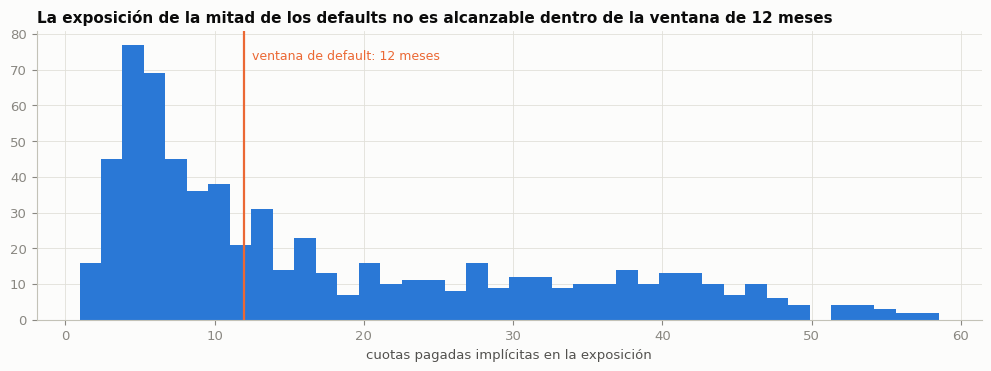

In [3]:
sev["mes_implicito_tasa_contrato"] = sv.implied_month_on_book(sev)                       # con la tasa ofrecida
sev["mes_implicito_tasa_ref"] = sv.implied_month_on_book(sev, cfg.REFERENCE_ANNUAL_RATE)  # robustez con la TEA de referencia
coherencia = pd.DataFrame({
    "con tasa del contrato": sev["mes_implicito_tasa_contrato"].describe(percentiles=[.25, .5, .75, .95]),
    "con TEA de referencia": sev["mes_implicito_tasa_ref"].describe(percentiles=[.25, .5, .75, .95])}).T
display(coherencia.round(2))
for col, etq in [("mes_implicito_tasa_contrato", "tasa del contrato"), ("mes_implicito_tasa_ref", "TEA de referencia")]:
    print(f"  {etq}: {(sev[col] > 12).mean():.1%} de los defaults implica más de 12 cuotas pagadas; "
          f"{(sev[col] > sev['term_months']).mean():.1%} supera el propio plazo")
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(sev["mes_implicito_tasa_contrato"], bins=40, color=BLUE)
ax.axvline(12, color=ORANGE, lw=1.6)
ax.text(12.5, ax.get_ylim()[1] * 0.9, "ventana de default: 12 meses", color=ORANGE, fontsize=9)
ax.set_xlabel("cuotas pagadas implícitas en la exposición"); ax.set_title("La exposición de la mitad de los defaults no es alcanzable dentro de la ventana de 12 meses")
fig.tight_layout(); savefig(fig, "fig28_ead_coherencia"); plt.show()

**Hallazgo.** La mitad de los defaults tiene una exposición que exigiría **más de 12 cuotas pagadas**, y la mediana implícita es de 11.6 meses con la tasa del contrato. Con un default definido dentro de los 12 meses de la originación, eso no es alcanzable con el calendario de amortización: los saldos del archivo están más amortizados de lo que el producto permite. La lectura benigna es que hubo prepagos parciales; la lectura de calidad de datos es que la exposición se generó de forma independiente del calendario.

*Consecuencia metodológica:* **no se puede estimar la EAD como "saldo teórico en el mes de default"**, que sería lo natural en un amortizable. Se modela el **factor de exposición** directamente sobre el monto desembolsado y se declara la limitación. En una cartera real, este chequeo sería un hallazgo para el dueño del dato antes de calcular provisiones.

## 3. EAD: baseline segmentado vs. modelos

In [4]:
VARIABLES_T0 = ["bureau_score", "dti_post", "term_months", "requested_amount", "monthly_income",
                "ahorro_sobre_monto", "age", "cash_income_share"]
def comparar(y, dev, val):
    cands = {
        "Baseline global": sv.SegmentedBaseline().fit(dev, y),
        "Baseline por plazo": sv.SegmentedBaseline(["term_months"], {"term_months": [0, 12, 24, 36, 60]}).fit(dev, y),
        "Baseline por banda de buró": sv.SegmentedBaseline(["bureau_score"], {"bureau_score": [0, 600, 660, 700, 900]}).fit(dev, y),
        "Baseline plazo x monto": sv.SegmentedBaseline(["term_months", "requested_amount"],
                                                       {"term_months": [0, 12, 36, 60], "requested_amount": [0, 5000, 15000, 1e9]}).fit(dev, y),
        "Logística fraccional": sv.FractionalLogit(VARIABLES_T0).fit(dev, y),
        "Boosting acotado": sv.BoundedGBM(VARIABLES_T0).fit(dev, y),
    }
    filas = []
    for n, m in cands.items():
        for s, df_ in [("DEV", dev), ("VAL", val)]:
            filas.append({"modelo": n, "muestra": s, **sv.evaluate(df_[y], m.predict(df_))})
    return cands, pd.DataFrame(filas).set_index(["modelo", "muestra"])[
        ["n", "mae", "rmse", "sesgo", "r2", "media_predicha", "media_observada"]]

modelos_ead, tabla_ead = comparar("ead_ratio", dev, val)
display(tabla_ead)
tabla_ead.to_csv(cfg.TABLES / "ead_comparacion_modelos.csv")
display(modelos_ead["Baseline por plazo"].table())

n    mae   rmse   sesgo      r2  media_predicha  media_observada
modelo                     muestra                                                                    
Baseline global            DEV      351 0.1509 0.1854  0.0000  0.0000          0.4154           0.4154
                           VAL      161 0.1590 0.1877  0.0054 -0.0008          0.4154           0.4099
Baseline por plazo         DEV      351 0.1509 0.1854 -0.0000  0.0008          0.4154           0.4154
                           VAL      161 0.1587 0.1872  0.0055  0.0039          0.4155           0.4099
Baseline por banda de buró DEV      351 0.1500 0.1842  0.0008  0.0131          0.4162           0.4154
                           VAL      161 0.1608 0.1892  0.0090 -0.0175          0.4190           0.4099
Baseline plazo x monto     DEV      351 0.1483 0.1840  0.0055  0.0152          0.4209           0.4154
                           VAL      161 0.1574 0.1884  0.0126 -0.0090          0.4225           0.4099
Logística fraccional       DEV      351 0.1487 0.1829  0.0000  0.0276          0.4154           0.4154
                           VAL      161 0.1632 0.1918  0.0027 -0.0457          0.4126           0.4099
Boosting acotado           DEV      351 0.1289 0.1567 -0.0000  0.2860          0.4154           0.4154
                           VAL      161 0.1696 0.1997  0.0104 -0.1325          0.4203           0.4099

,casos,promedio_observado,estimacion
"(0, 12]",140,0.4141,0.4141
"(12, 24]",78,0.4210,0.4210
"(24, 36]",42,0.4234,0.4234
"(36, 60]",91,0.4089,0.4089


,casos,observado,estimado,sesgo,mae
seg,,,,,
"(0, 12]",62.0000,0.4073,0.4154,0.0081,0.1501
"(12, 24]",43.0000,0.4600,0.4154,-0.0446,0.1694
"(36, 60]",41.0000,0.3776,0.4154,0.0378,0.1606
"(24, 36]",15.0000,0.3659,0.4154,0.0495,0.1614


,size,mean,std
observation_date,,,
2021,102,0.3960,0.1920
2022,111,0.4250,0.1860
2023,138,0.4220,0.1810
2024,161,0.4100,0.1880
2025,159,0.4300,0.1900


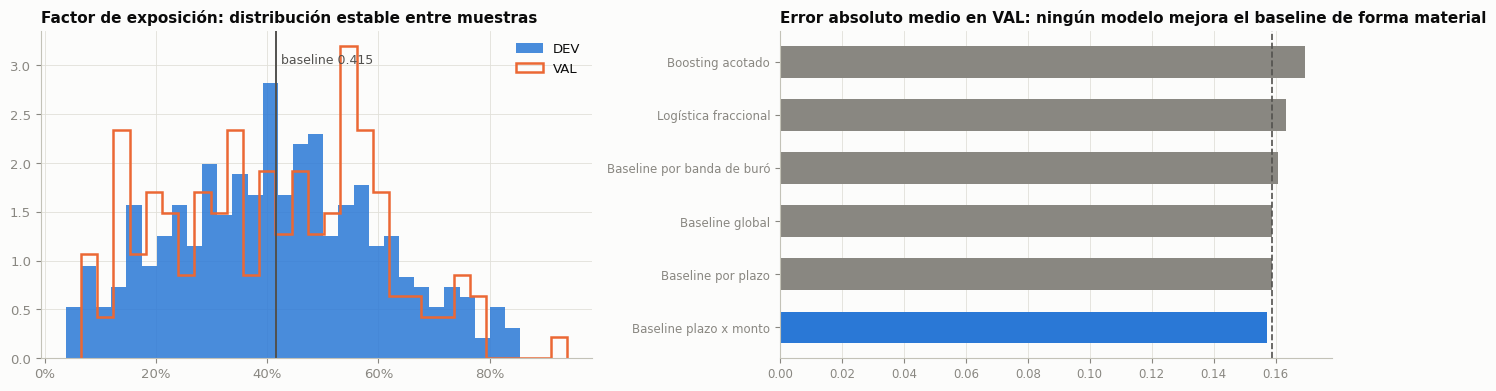

In [5]:
base_ead = modelos_ead["Baseline global"]
seg = pd.cut(val["term_months"], [0, 12, 24, 36, 60]).astype(str)
err_ead = sv.error_by_segment(val, "ead_ratio", base_ead.predict(val), seg)
display(err_ead)
err_ead.to_csv(cfg.TABLES / "ead_error_por_segmento.csv")
por_anio = sev.groupby(sev[cfg.DATE_COL].dt.year)["ead_ratio"].agg(["size", "mean", "std"])
display(por_anio.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
axes[0].hist(dev["ead_ratio"], bins=30, color=BLUE, alpha=0.85, density=True, label="DEV")
axes[0].hist(val["ead_ratio"], bins=30, color=ORANGE, histtype="step", lw=1.8, density=True, label="VAL")
axes[0].axvline(base_ead.global_, color=INK_2, lw=1.4)
axes[0].text(base_ead.global_ + 0.01, axes[0].get_ylim()[1] * 0.9, f"baseline {base_ead.global_:.3f}", color=INK_2, fontsize=9)
axes[0].set_title("Factor de exposición: distribución estable entre muestras"); axes[0].legend(); pct_axis(axes[0], axis="x")
t_ = tabla_ead.xs("VAL", level="muestra").sort_values("mae")
axes[1].barh(t_.index, t_["mae"], color=[BLUE if i == t_["mae"].idxmin() else MUTED for i in t_.index], height=0.6)
axes[1].axvline(tabla_ead.loc[("Baseline global", "VAL"), "mae"], color=INK_2, lw=1.2, ls="--")
axes[1].set_title("Error absoluto medio en VAL: ningún modelo mejora el baseline de forma material")
axes[1].grid(axis="y", visible=False); axes[1].tick_params(labelsize=8.5)
fig.tight_layout(); savefig(fig, "fig29_ead_modelos"); plt.show()

**Decisión: baseline global, factor de exposición = 0.415 (promedio de DEV).**

- **Ninguna variable de T0 explica la exposición.** La logística fraccional pasa de R² 0.028 en DEV a **−0.046 en VAL** y el boosting, de 0.286 a **−0.133**: es sobreajuste puro, el caso de manual de un modelo que memoriza 351 casos.
- **Segmentar tampoco aporta.** Por plazo el R² en VAL es 0.004 y por banda de buró, negativo. El factor es plano: 0.409 a 0.423 entre tramos de plazo.
- **La estabilidad es buena.** El promedio va de 0.396 a 0.430 entre cosechas y de 0.415 (DEV) a 0.410 (VAL): el sesgo del baseline en VAL es +0.5 puntos porcentuales sobre una media de 41%.
- El error absoluto medio de 0.159 sobre una media de 0.41 es alto en términos relativos, pero es **irreducible con esta información**: refleja la dispersión del propio dato (desviación estándar 0.19), no una mala especificación.

## 4. LGD: descomposición, recuperaciones, costos y workout

Identidad LGD = (EAD − recuperaciones + costos) / EAD, error máximo: 6.05e-05


,count,mean,std,min,5%,50%,95%,max
Recuperación / EAD,671.0000,0.4210,0.1470,0.0370,0.1820,0.4220,0.6580,0.9180
Costo de recuperación / EAD,671.0000,0.0440,0.0200,0.0100,0.0130,0.0450,0.0760,0.0800
LGD contable,671.0000,0.6230,0.1450,0.1320,0.3900,0.6210,0.8620,0.9800
Meses de workout,671.0000,11.9700,7.2340,1.0000,3.0000,11.0000,25.0000,44.0000


LGD en los extremos: casos con LGD = 0: 0 | con LGD = 1: 0 | por encima de 0.95: 13 | por debajo de 0.20: 3


,lgd,recuperacion_sobre_ead,costo_sobre_ead,months_to_recovery
observation_date,,,,
2021,0.6190,0.4260,0.0460,12.0880
2022,0.6160,0.4250,0.0410,11.5140
2023,0.6150,0.4290,0.0440,12.6450
2024,0.6260,0.4190,0.0450,12.1930
2025,0.6340,0.4110,0.0450,11.4030


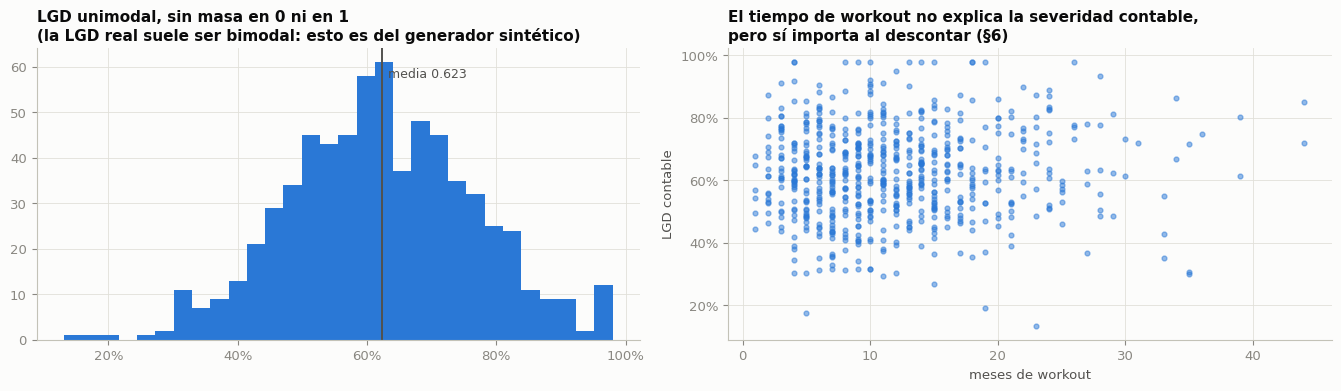

In [6]:
print(f"Identidad LGD = (EAD − recuperaciones + costos) / EAD, error máximo: "
      f"{float(((sev.ead_at_default - sev.recovery_amount_total + sev.recovery_cost_total) / sev.ead_at_default - sev.lgd).abs().max()):.2e}")
desc = pd.DataFrame({
    "Recuperación / EAD": sev["recuperacion_sobre_ead"], "Costo de recuperación / EAD": sev["costo_sobre_ead"],
    "LGD contable": sev["lgd"], "Meses de workout": sev["months_to_recovery"]}).describe(percentiles=[.05, .5, .95]).T
display(desc.round(3))
print("LGD en los extremos: casos con LGD = 0:", int((sev.lgd <= 0).sum()), "| con LGD = 1:", int((sev.lgd >= 1).sum()),
      "| por encima de 0.95:", int((sev.lgd > 0.95).sum()), "| por debajo de 0.20:", int((sev.lgd < 0.20).sum()))
display(sev.groupby(sev[cfg.DATE_COL].dt.year)[["lgd", "recuperacion_sobre_ead", "costo_sobre_ead", "months_to_recovery"]].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
axes[0].hist(sev["lgd"], bins=30, color=BLUE)
axes[0].axvline(sev["lgd"].mean(), color=INK_2, lw=1.4)
axes[0].text(sev["lgd"].mean() + 0.01, axes[0].get_ylim()[1] * 0.9, f"media {sev['lgd'].mean():.3f}", color=INK_2, fontsize=9)
axes[0].set_title("LGD unimodal, sin masa en 0 ni en 1\n(la LGD real suele ser bimodal: esto es del generador sintético)")
pct_axis(axes[0], axis="x")
axes[1].scatter(sev["months_to_recovery"], sev["lgd"], s=12, color=BLUE, alpha=0.5)
axes[1].set_xlabel("meses de workout"); axes[1].set_ylabel("LGD contable"); pct_axis(axes[1])
axes[1].set_title("El tiempo de workout no explica la severidad contable,\npero sí importa al descontar (§6)")
fig.tight_layout(); savefig(fig, "fig30_lgd_distribucion"); plt.show()

## 5. LGD: baseline segmentado vs. modelos

In [7]:
modelos_lgd, tabla_lgd = comparar("lgd", dev, val)
display(tabla_lgd)
tabla_lgd.to_csv(cfg.TABLES / "lgd_comparacion_modelos.csv")
print("Coeficientes estandarizados de la logística fraccional:")
display(modelos_lgd["Logística fraccional"].coef_.round(3).to_frame("coef"))

base_lgd = modelos_lgd["Baseline global"]
seg_lgd = pd.cut(val["bureau_score"], [0, 600, 660, 700, 900]).astype(str).fillna("Sin score")
err_lgd = sv.error_by_segment(val, "lgd", base_lgd.predict(val), seg_lgd)
display(err_lgd)
err_lgd.to_csv(cfg.TABLES / "lgd_error_por_segmento.csv")

n    mae   rmse   sesgo      r2  media_predicha  media_observada
modelo                     muestra                                                                    
Baseline global            DEV      351 0.1103 0.1403  0.0000  0.0000          0.6164           0.6164
                           VAL      161 0.1254 0.1553 -0.0096 -0.0038          0.6164           0.6260
Baseline por plazo         DEV      351 0.1108 0.1396  0.0000  0.0103          0.6164           0.6164
                           VAL      161 0.1254 0.1562 -0.0080 -0.0157          0.6180           0.6260
Baseline por banda de buró DEV      351 0.1098 0.1396 -0.0022  0.0099          0.6143           0.6164
                           VAL      161 0.1248 0.1559 -0.0140 -0.0117          0.6120           0.6260
Baseline plazo x monto     DEV      351 0.1102 0.1396  0.0029  0.0101          0.6193           0.6164
                           VAL      161 0.1256 0.1548 -0.0079  0.0019          0.6181           0.6260
Logística fraccional       DEV      351 0.1084 0.1375 -0.0000  0.0397          0.6164           0.6164
                           VAL      161 0.1235 0.1551 -0.0152 -0.0025          0.6108           0.6260
Boosting acotado           DEV      351 0.0943 0.1198 -0.0000  0.2713          0.6164           0.6164
                           VAL      161 0.1333 0.1651 -0.0156 -0.1355          0.6104           0.6260

Coeficientes estandarizados de la logística fraccional:


,coef
bureau_score,-0.0720
dti_post,-0.0000
term_months,0.0160
requested_amount,-0.0620
monthly_income,0.0180
ahorro_sobre_monto,-0.0800
age,-0.0000
cash_income_share,0.0310


,casos,observado,estimado,sesgo,mae
seg,,,,,
"(600, 660]",55.0000,0.6533,0.6164,-0.0368,0.1374
"(0, 600]",46.0000,0.6496,0.6164,-0.0331,0.1166
"(660, 700]",29.0000,0.5757,0.6164,0.0407,0.1289
"(700, 900]",28.0000,0.5977,0.6164,0.0188,0.1019
nan,3.0000,0.5169,0.6164,0.0995,0.2241


**Decisión: baseline global, LGD = 0.616 (promedio de DEV).**

- **Tampoco hay señal en T0.** El coeficiente más grande de la logística fraccional es el del ahorro sobre monto (−0.08) y el del buró (−0.07), ambos chicos; el modelo mejora el MAE de VAL en 0.002 y deja R² negativo. El boosting vuelve a sobreajustar (R² 0.27 en DEV, −0.14 en VAL).
- **Los baselines segmentados empatan con el global**, así que se prefiere el más simple y el más estable de estimar.
- **El sesgo es el punto a vigilar**, no el error: el baseline ajustado en DEV subestima la LGD de VAL en 1 punto (0.616 contra 0.626 observado). Es chico, pero va en la dirección peligrosa, así que la LGD entra al monitoreo con revisión anual.

## 6. LGD económica (descontada) y LGD de downturn

La LGD del archivo **suma soles de momentos distintos**: recupera en promedio a los 12 meses y no descuenta. Basilea e IFRS 9 piden LGD económica, descontada a la tasa efectiva del contrato. La diferencia no es cosmética.

In [8]:
filas = []
for tasa in [0.10, 0.20, 0.30, float(sev["annual_interest_rate_offer"].mean())]:
    e = sv.lgd_economica(sev, tasa)
    filas.append({"tasa_de_descuento": tasa, "lgd_economica": e.mean(),
                  "diferencia_vs_contable": e.mean() - sev["lgd"].mean(),
                  "el_relativo": e.mean() / sev["lgd"].mean()})
economica = pd.DataFrame(filas).set_index("tasa_de_descuento")
display(economica.round(4))
economica.to_csv(cfg.TABLES / "lgd_economica.csv")

# Downturn: se calcula con DEV y VAL; la cosecha OOT queda como confirmación.
dev_val = sev[sev["sample"].isin(["DEV", "VAL"])]
down = sv.downturn_lgd(dev_val)
print("Downturn (DEV + VAL):", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in down.items()})
print("Confirmación en OOT 2025: LGD media", round(float(oot["lgd"].mean()), 4))

,lgd_economica,diferencia_vs_contable,el_relativo
tasa_de_descuento,,,
0.1000,0.6600,0.0372,1.0597
0.2000,0.6902,0.0673,1.1080
0.3000,0.7151,0.0922,1.1480
0.3189,0.7193,0.0964,1.1548


Downturn (DEV + VAL): {'promedio_largo_plazo': 0.6195, 'peor_cosecha': 0.626, 'anio_peor_cosecha': 2024, 'recargo_downturn': 0.0066}
Confirmación en OOT 2025: LGD media 0.6339


**Dos números que cambian decisiones:**

1. **LGD económica.** Descontando al 10% anual la LGD sube de 0.623 a 0.660; a la tasa media del contrato (31.9%), a 0.719. Es decir, la pérdida esperada calculada con la LGD contable **subestima entre 6% y 15%**. Recomendación: adoptar la LGD económica para provisiones y Expected Loss, y **restatear en la misma base el umbral de pérdida esperada del apetito** (si se cambia la métrica sin cambiar el umbral, el semáforo se rompe por definición, no por riesgo).
2. **LGD de downturn.** La peor cosecha de DEV y VAL da 0.626 contra 0.619 de promedio de largo plazo: un recargo de apenas 0.7 puntos. La severidad de esta cartera **casi no cicla**, lo que confirma el hallazgo 13 de 6.4: la pérdida creció por frecuencia (PD), no por severidad. El escenario de stress de 6.12 debe cargar sobre la PD y usar un recargo chico en LGD.

## 7. Parámetros recomendados, artefacto y trazabilidad

In [9]:
import json as _json
oot_ead, oot_lgd = float(oot["ead_ratio"].mean()), float(oot["lgd"].mean())
parametros = {
    "version": "ead_lgd_v1", "secciones": ["6.10", "6.11"],
    "poblacion": {"defaults": int(len(sev)), "dev": int(len(dev)), "val": int(len(val)), "oot": int(len(oot))},
    "ead": {"metodo": "baseline global (factor sobre monto desembolsado)", "factor": round(float(dev["ead_ratio"].mean()), 4),
            "mae_val": round(float(tabla_ead.loc[("Baseline global", "VAL"), "mae"]), 4),
            "nota": "no se usa CCF: el producto es amortizable sin línea (ccf_observed vacío)"},
    "lgd": {"metodo": "baseline global", "lgd_contable": round(float(dev["lgd"].mean()), 4),
            "lgd_economica_10": round(float(sv.lgd_economica(dev, 0.10).mean()), 4),
            "lgd_downturn_dev_val": round(float(down["peor_cosecha"]), 4),
            "mae_val": round(float(tabla_lgd.loc[("Baseline global", "VAL"), "mae"]), 4)},
    "confirmacion_oot": {"ead_ratio": round(oot_ead, 4), "lgd": round(oot_lgd, 4)},
}
(cfg.ROOT / "models" / "ead_lgd_v1.json").write_text(_json.dumps(parametros, ensure_ascii=False, indent=2), encoding="utf-8")
print(_json.dumps(parametros, ensure_ascii=False, indent=2))
print("\nParámetros en config (usados por 6.9 y 6.12):", {"EAD_FACTOR_BASELINE": cfg.EAD_FACTOR_BASELINE, "LGD_BASELINE": cfg.LGD_BASELINE})

{
  "version": "ead_lgd_v1",
  "secciones": [
    "6.10",
    "6.11"
  ],
  "poblacion": {
    "defaults": 671,
    "dev": 351,
    "val": 161,
    "oot": 159
  },
  "ead": {
    "metodo": "baseline global (factor sobre monto desembolsado)",
    "factor": 0.4154,
    "mae_val": 0.159,
    "nota": "no se usa CCF: el producto es amortizable sin línea (ccf_observed vacío)"
  },
  "lgd": {
    "metodo": "baseline global",
    "lgd_contable": 0.6164,
    "lgd_economica_10": 0.6545,
    "lgd_downturn_dev_val": 0.626,
    "mae_val": 0.1254
  },
  "confirmacion_oot": {
    "ead_ratio": 0.4301,
    "lgd": 0.6339
  }
}

Parámetros en config (usados por 6.9 y 6.12): {'EAD_FACTOR_BASELINE': 0.415, 'LGD_BASELINE': 0.616}


**Confirmación en OOT.** Con los parámetros congelados en DEV, la cosecha 2025 da 0.430 de factor de exposición contra 0.415 estimado (+1.5 pp) y 0.634 de LGD contra 0.616 (+1.8 pp). Las dos desviaciones van en la dirección conservadora que hay que vigilar, pero están dentro de la variación entre cosechas y **no justifican cambiar los parámetros**: entran al plan de monitoreo con revisión anual.

| Requisito | Dónde se cumple |
|---|---|
| 6.10 · Variable respuesta y población definidas | §1 · `severity.build_severity_frame` |
| 6.10 · Producto amortizable: estimar EAD con metodología defendible y contrastar con baseline segmentado | §2 y §3 · `ead_comparacion_modelos.csv` · `fig28`, `fig29` |
| 6.10 · Error, sesgo y estabilidad por segmentos; limitaciones | §3 · `ead_error_por_segmento.csv` · hallazgo de coherencia en §2 |
| 6.11 · Trabajar sobre cuentas en default con recuperación | §1 y §4 |
| 6.11 · Baseline segmentado + modelo apropiado para variable acotada | §5 · `lgd_comparacion_modelos.csv` |
| 6.11 · Recuperaciones, costos, tiempo de workout y extremos | §4 y §6 · `fig30` · `lgd_economica.csv` |
| 6.11 · Precisión, sesgo y estabilidad por segmentos | §5 · `lgd_error_por_segmento.csv` · confirmación OOT en §7 |